# Baselines Analysis
Load, aggregate, and visualize EWT / CoNLL / WIESP single-domain baselines (3 seeds each).

## Cell 1 — Imports & Style Configuration

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Aesthetic constants ───────────────────────────────────────────────────────
BG   = "#f6f1eb"
DARK = "#2f241f"
EDGE = "#3d3128"
GRID = "#8b6f5a"

DOMAIN_COLORS = {
    "EWT":   "#EFA6C1",
    "CONLL": "#8FD3B6",
    "WIESP": "#F4B183",
}

EXPNAME_TO_DOMAIN = {
    "baseline_ewt_only":   "EWT",
    "baseline_conll_only": "CONLL",
    "baseline_astro_only": "WIESP",
}

EVALSET_TO_DOMAIN = {
    "ewt_dev":    "EWT",
    "conll_test": "CONLL",
    "astro_test": "WIESP",
}

EXPNAME_LABELS = {
    "baseline_ewt_only":   "EWT Only",
    "baseline_conll_only": "CoNLL Only",
    "baseline_astro_only": "WIESP Only",
}

EVALSET_LABELS = {
    "ewt_dev":    "EWT Dev",
    "conll_test": "CoNLL Test",
    "astro_test": "WIESP Test",
}

# Filesystem directory names under runs/baselines/
EXPNAME_TO_DIR = {
    "baseline_ewt_only":   "ewt_only",
    "baseline_conll_only": "conll_only",
    "baseline_astro_only": "astro_only",
}

BASELINES_ORDER = ["baseline_ewt_only", "baseline_conll_only", "baseline_astro_only"]
EVALSETS_ORDER  = ["ewt_dev", "conll_test", "astro_test"]

# Actual column names in the summary CSVs
F1_COL        = "entity_f1_micro"
PRECISION_COL = "entity_precision"
RECALL_COL    = "entity_recall"

plt.rcParams.update({
    "font.family":       "DejaVu Serif",
    "axes.facecolor":    BG,
    "figure.facecolor":  BG,
    "axes.edgecolor":    EDGE,
    "axes.linewidth":    0.8,
    "text.color":        DARK,
    "axes.labelcolor":   DARK,
    "xtick.color":       DARK,
    "ytick.color":       DARK,
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

## Cell 2 — Data Loading

In [2]:
runs_root = Path("runs")

dfs = []
for b_dir in ["ewt_only", "conll_only", "astro_only"]:
    path = runs_root / "baselines" / b_dir / "summary.csv"
    tmp = pd.read_csv(path)
    print(f"--- {b_dir} ---  shape={tmp.shape}")
    display(tmp.head(3))
    print()
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

df["domain"]      = df["exp_name"].map(EXPNAME_TO_DOMAIN)
df["eval_domain"] = df["eval_set"].map(EVALSET_TO_DOMAIN)

print(f"Combined df shape: {df.shape}")

--- ewt_only ---  shape=(9, 83)


,exp_name,seed,iteration,n_blocks,n_target_examples,n_source_examples,train_set_size,target_fraction,eval_set,entity_f1_micro,...,support_Software,support_Survey,support_Tag,support_Telescope,support_TextGarbage,support_URL,support_Wavelength,best_epoch,train_time_sec,peak_gpu_mem_mb
0,baseline_ewt_only,42,0,0,0,12543,12543,NaN,ewt_dev,0.804890,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,761.025057,5586
1,baseline_ewt_only,42,0,0,0,12543,12543,NaN,conll_test,0.702273,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,761.025057,5586
2,baseline_ewt_only,42,0,0,0,12543,12543,NaN,astro_test,0.309910,...,1112.0,915.0,74.0,1881.0,192.0,350.0,3151.0,7,761.025057,5586



--- conll_only ---  shape=(9, 83)


,exp_name,seed,iteration,n_blocks,n_target_examples,n_source_examples,train_set_size,target_fraction,eval_set,entity_f1_micro,...,support_Software,support_Survey,support_Tag,support_Telescope,support_TextGarbage,support_URL,support_Wavelength,best_epoch,train_time_sec,peak_gpu_mem_mb
0,baseline_conll_only,42,0,0,0,14041,14041,NaN,ewt_dev,0.740519,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,1081.858861,5004
1,baseline_conll_only,42,0,0,0,14041,14041,NaN,conll_test,0.924056,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,1081.858861,5004
2,baseline_conll_only,42,0,0,0,14041,14041,NaN,astro_test,0.262401,...,1112.0,915.0,74.0,1881.0,192.0,350.0,3151.0,13,1081.858861,5004



--- astro_only ---  shape=(9, 83)


,exp_name,seed,iteration,n_blocks,n_target_examples,n_source_examples,train_set_size,target_fraction,eval_set,entity_f1_micro,...,support_Software,support_Survey,support_Tag,support_Telescope,support_TextGarbage,support_URL,support_Wavelength,best_epoch,train_time_sec,peak_gpu_mem_mb
0,baseline_astro_only,42,0,0,0,1816,1816,NaN,ewt_dev,0.392523,...,0,0,0.0,0,0.0,0,0,53,4361.063478,11763
1,baseline_astro_only,42,0,0,0,1816,1816,NaN,conll_test,0.506946,...,0,0,0.0,0,0.0,0,0,53,4361.063478,11763
2,baseline_astro_only,42,0,0,0,1816,1816,NaN,astro_test,0.739612,...,1112,915,74.0,1881,192.0,350,3151,53,4361.063478,11763



Combined df shape: (27, 85)


## Cell 3 — Sanity Checks

In [3]:
print("=== Seeds & eval sets per baseline ===")
for b in BASELINES_ORDER:
    sub = df[df["exp_name"] == b]
    print(f"  {EXPNAME_LABELS[b]}:")
    print(f"    seeds    : {sorted(sub['seed'].unique())}")
    print(f"    eval_sets: {sorted(sub['eval_set'].unique())}")

print(f"\nFull df shape: {df.shape}")

nan_f1 = df[F1_COL].isna().sum()
print(f"Missing {F1_COL} values: {nan_f1}")

pivot = (
    df.groupby(["exp_name", "eval_set"])[F1_COL]
      .mean()
      .unstack("eval_set")
)
pivot.index   = [EXPNAME_LABELS[i] for i in pivot.index]
pivot.columns = [EVALSET_LABELS[c] for c in pivot.columns]
print(f"\nMean {F1_COL} across seeds:")
print(pivot.applymap(lambda x: f"{x:.3f}"))

=== Seeds & eval sets per baseline ===
  EWT Only:
    seeds    : [42, 123, 456]
    eval_sets: ['astro_test', 'conll_test', 'ewt_dev']
  CoNLL Only:
    seeds    : [42, 123, 456]
    eval_sets: ['astro_test', 'conll_test', 'ewt_dev']
  WIESP Only:
    seeds    : [42, 123, 456]
    eval_sets: ['astro_test', 'conll_test', 'ewt_dev']

Full df shape: (27, 85)
Missing entity_f1_micro values: 0

Mean entity_f1_micro across seeds:
           WIESP Test CoNLL Test EWT Dev
WIESP Only      0.740      0.510   0.422
CoNLL Only      0.273      0.921   0.738
EWT Only        0.282      0.705   0.805


## Cell 4 — Aggregation: Mean ± Std Across Seeds

In [4]:
f1_type_cols      = [c for c in df.columns if c.startswith("f1_")]
support_type_cols = [c for c in df.columns if c.startswith("support_")]
main_cols = [PRECISION_COL, RECALL_COL, F1_COL]
all_agg_cols = main_cols + f1_type_cols + support_type_cols

agg = (
    df.groupby(["exp_name", "eval_set"])[all_agg_cols]
      .agg(["mean", "std"])
)
agg.columns = ["_".join(c) for c in agg.columns]
agg_df = agg.reset_index()

display_cols = [
    "exp_name", "eval_set",
    f"{PRECISION_COL}_mean", f"{RECALL_COL}_mean",
    f"{F1_COL}_mean",        f"{F1_COL}_std",
]
print("Aggregated metrics (mean ± std across 3 seeds):")
print(agg_df[display_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Aggregated metrics (mean ± std across 3 seeds):
           exp_name   eval_set  entity_precision_mean  entity_recall_mean  entity_f1_micro_mean  entity_f1_micro_std
baseline_astro_only astro_test                 0.7335              0.7474                0.7404               0.0015
baseline_astro_only conll_test                 0.4583              0.5739                0.5096               0.0026
baseline_astro_only    ewt_dev                 0.3548              0.5200                0.4218               0.0304
baseline_conll_only astro_test                 0.4114              0.2056                0.2735               0.0170
baseline_conll_only conll_test                 0.9169              0.9258                0.9213               0.0042
baseline_conll_only    ewt_dev                 0.7023              0.7785                0.7383               0.0068
  baseline_ewt_only astro_test                 0.4700              0.2020                0.2823               0.0239
  baseline_ewt_o

## Cell 5 — Plot 1: Overall F1 — Grouped Bar Chart

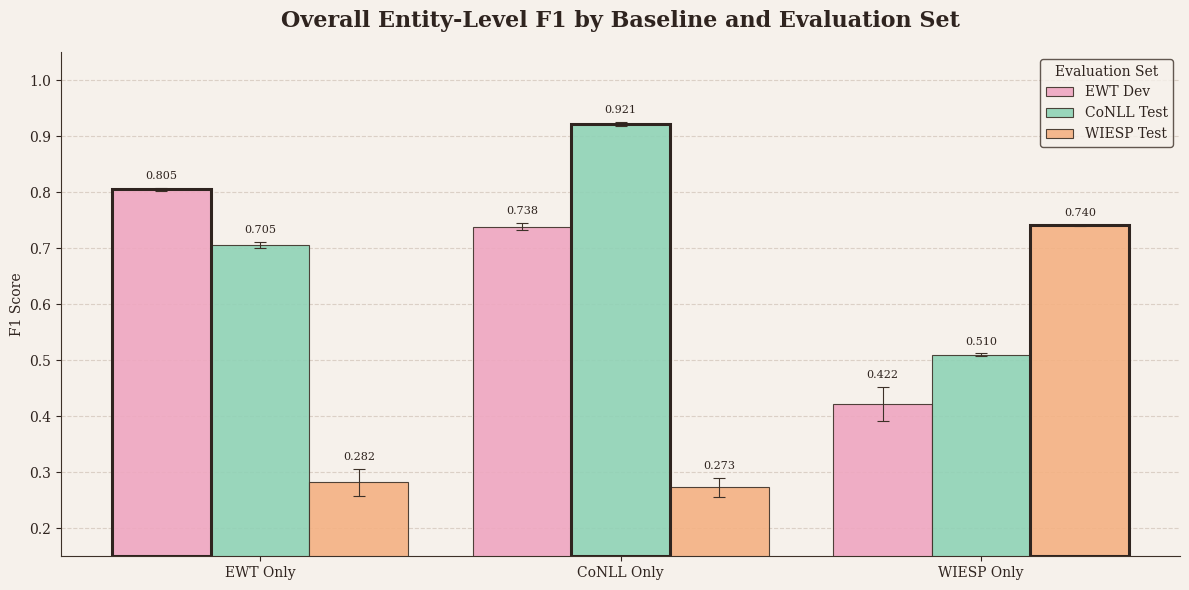

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

n_baselines = len(BASELINES_ORDER)
n_evalsets  = len(EVALSETS_ORDER)
bar_width   = 0.22
group_gap   = 0.10
x           = np.arange(n_baselines) * (n_evalsets * bar_width + group_gap + bar_width * 0.2)

all_bars = {}  # (baseline_idx, evalset_idx) → bar patch

for i, es in enumerate(EVALSETS_ORDER):
    offsets = x + i * bar_width
    means, stds = [], []
    for b in BASELINES_ORDER:
        row = agg_df[(agg_df["exp_name"] == b) & (agg_df["eval_set"] == es)]
        if len(row):
            means.append(float(row[f"{F1_COL}_mean"].iloc[0]))
            stds.append( float(row[f"{F1_COL}_std"].iloc[0]))
        else:
            means.append(0.0); stds.append(0.0)

    color = DOMAIN_COLORS[EVALSET_TO_DOMAIN[es]]
    bars = ax.bar(
        offsets, means, bar_width,
        yerr=stds, capsize=4,
        color=color, alpha=0.9,
        edgecolor=EDGE, linewidth=0.8,
        label=EVALSET_LABELS[es],
        error_kw=dict(ecolor=EDGE, elinewidth=0.8, capthick=0.8),
    )
    for j, (bar, m, s) in enumerate(zip(bars, means, stds)):
        all_bars[(j, i)] = bar
        if m > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + s + 0.012,
                f"{m:.3f}",
                ha="center", va="bottom",
                fontsize=8, color=DARK,
            )

# In-domain bold borders: baseline idx == evalset idx in BASELINES/EVALSETS_ORDER
yfloor = 0.15
for idx in range(3):
    bar = all_bars.get((idx, idx))
    if bar is not None and bar.get_height() > yfloor:
        rect = plt.Rectangle(
            (bar.get_x(), yfloor),
            bar.get_width(),
            bar.get_height() - yfloor,
            fill=False,
            edgecolor=DARK,
            linewidth=2.2,
            zorder=5,
        )
        ax.add_patch(rect)

ax.set_xticks(x + bar_width * (n_evalsets - 1) / 2)
ax.set_xticklabels([EXPNAME_LABELS[b] for b in BASELINES_ORDER], rotation=0, color=DARK)
ax.set_ylabel("F1 Score", color=DARK)
ax.set_ylim(0.15, 1.05)
ax.set_title(
    "Overall Entity-Level F1 by Baseline and Evaluation Set",
    fontweight="bold", color=DARK, fontsize=16, pad=18,
)
ax.yaxis.grid(True, linestyle="--", alpha=0.25, color=GRID)
ax.set_axisbelow(True)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
for sp in ["left", "bottom"]:
    ax.spines[sp].set_color(EDGE); ax.spines[sp].set_linewidth(0.8)

legend = ax.legend(title="Evaluation Set", loc="upper right",
                   framealpha=0.8, facecolor=BG, edgecolor=EDGE)
legend.get_title().set_color(DARK)
for text in legend.get_texts():
    text.set_color(DARK)

plt.tight_layout()
plt.show()

## Cell 6 — Plot 2: Per-Entity-Type F1 Heatmap

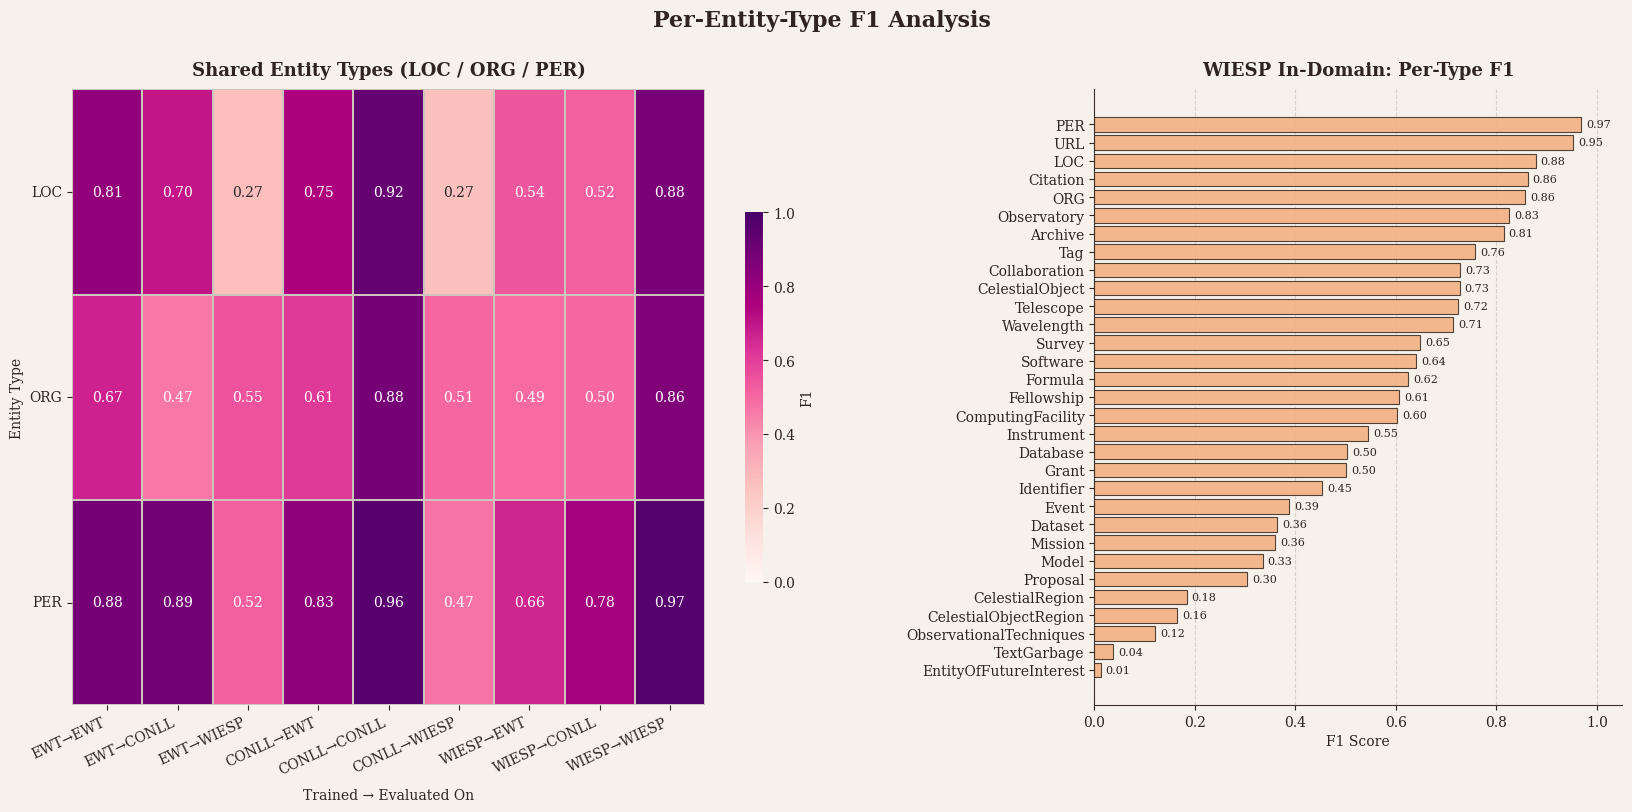

In [6]:
import matplotlib.gridspec as gridspec

f1_type_cols = [c for c in df.columns if c.startswith("f1_")]
type_names   = [c[3:] for c in f1_type_cols]

# Build full baseline×eval matrix
col_labels, f1_vals, supp_vals = [], [], []
for b in BASELINES_ORDER:
    b_dom = EXPNAME_TO_DOMAIN[b]
    for es in EVALSETS_ORDER:
        es_dom = EVALSET_TO_DOMAIN[es]
        col_labels.append(f"{b_dom}→{es_dom}")
        row = agg_df[(agg_df["exp_name"] == b) & (agg_df["eval_set"] == es)]
        if len(row):
            r = row.iloc[0]
            f1_vals.append([r[f"f1_{t}_mean"]   if f"f1_{t}_mean"   in r.index else np.nan for t in type_names])
            supp_vals.append([r[f"support_{t}_mean"] if f"support_{t}_mean" in r.index else 0.0  for t in type_names])
        else:
            f1_vals.append([np.nan] * len(type_names))
            supp_vals.append([0.0]  * len(type_names))

f1_matrix = pd.DataFrame(np.array(f1_vals).T, index=type_names, columns=col_labels)

# Subplot A data: shared types only
shared_types = ["LOC", "ORG", "PER"]
f1_shared = f1_matrix.loc[shared_types].fillna(0.0)

# Subplot B data: WIESP in-domain, types with f1 > 0, sorted ascending for barh
wiesp_col = "WIESP→WIESP"
wiesp_f1  = f1_matrix[wiesp_col].dropna()
wiesp_f1  = wiesp_f1[wiesp_f1 > 0].sort_values(ascending=True)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 8))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.35)
ax_l = fig.add_subplot(gs[0])
ax_r = fig.add_subplot(gs[1])

# ── Subplot A: shared-types heatmap ──────────────────────────────────────────
ax_l.set_facecolor(BG)
sns.heatmap(
    f1_shared, ax=ax_l,
    cmap="RdPu", vmin=0, vmax=1,
    annot=True, fmt=".2f",
    linewidths=0.3, linecolor="#ccc5bc",
    cbar_kws={"shrink": 0.6, "label": "F1"},
)
ax_l.set_facecolor(BG)
ax_l.set_title("Shared Entity Types (LOC / ORG / PER)",
               fontweight="bold", color=DARK, fontsize=13, pad=10)
ax_l.set_xlabel("Trained → Evaluated On", color=DARK, labelpad=8)
ax_l.set_ylabel("Entity Type", color=DARK)
ax_l.tick_params(colors=DARK)
plt.setp(ax_l.get_xticklabels(), rotation=25, ha="right", color=DARK)
plt.setp(ax_l.get_yticklabels(), rotation=0,  color=DARK)
for sp in ["top", "right"]:
    ax_l.spines[sp].set_visible(False)
for sp in ["left", "bottom"]:
    ax_l.spines[sp].set_color(EDGE); ax_l.spines[sp].set_linewidth(0.8)

# ── Subplot B: WIESP in-domain barh ──────────────────────────────────────────
ax_r.set_facecolor(BG)
bars = ax_r.barh(
    wiesp_f1.index, wiesp_f1.values,
    color=DOMAIN_COLORS["WIESP"], alpha=0.9,
    edgecolor=EDGE, linewidth=0.8,
)
for bar, val in zip(bars, wiesp_f1.values):
    ax_r.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
              f"{val:.2f}", va="center", ha="left", fontsize=8, color=DARK)

ax_r.set_xlim(0, 1.05)
ax_r.set_xlabel("F1 Score", color=DARK)
ax_r.set_title("WIESP In-Domain: Per-Type F1",
               fontweight="bold", color=DARK, fontsize=13, pad=10)
ax_r.xaxis.grid(True, linestyle="--", alpha=0.25, color=GRID)
ax_r.set_axisbelow(True)
ax_r.tick_params(colors=DARK)
plt.setp(ax_r.get_xticklabels(), color=DARK)
plt.setp(ax_r.get_yticklabels(), color=DARK)
for sp in ["top", "right"]:
    ax_r.spines[sp].set_visible(False)
for sp in ["left", "bottom"]:
    ax_r.spines[sp].set_color(EDGE); ax_r.spines[sp].set_linewidth(0.8)

fig.suptitle("Per-Entity-Type F1 Analysis",
             fontweight="bold", color=DARK, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Cell 7 — Plot 3: Precision / Recall / F1 Summary Table

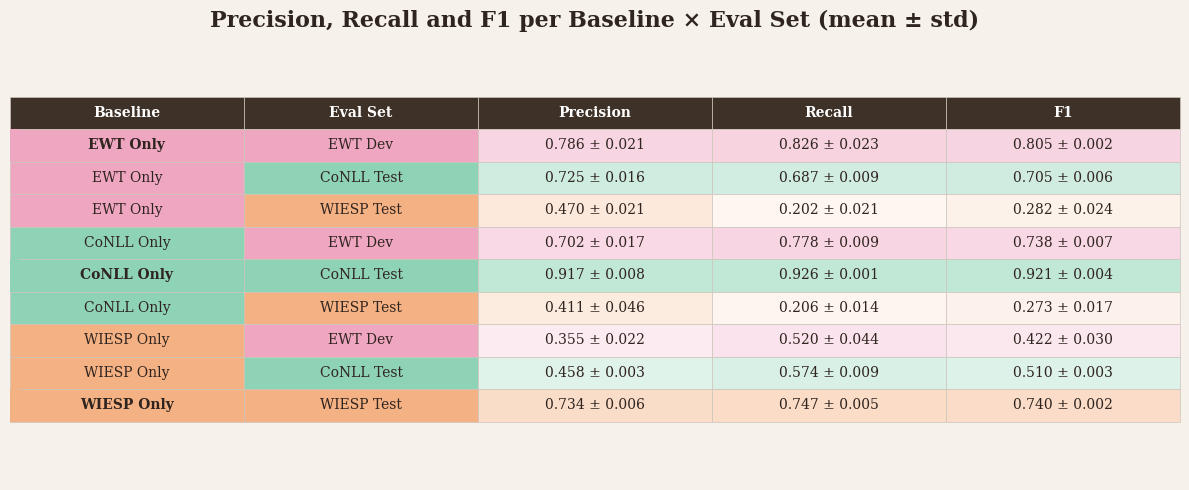

In [7]:
import matplotlib.colors as mc

def metric_cell_color(value, domain_hex):
    """White → domain color (60% max saturation), interpolated by value."""
    if np.isnan(value):
        return BG
    v = float(np.clip(value, 0, 1))
    base  = np.array(mc.to_rgb(domain_hex))
    white = np.ones(3)
    return tuple(white + 0.6 * v * (base - white))

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.axis("off")
ax.set_title(
    "Precision, Recall and F1 per Baseline × Eval Set (mean ± std)",
    fontweight="bold", color=DARK, fontsize=16, pad=8,
)

col_headers = ["Baseline", "Eval Set", "Precision", "Recall", "F1"]
table_data  = []
cell_colors = []
row_meta    = []  # (b, es) per data row for post-processing

p_mean_col  = f"{PRECISION_COL}_mean"
p_std_col   = f"{PRECISION_COL}_std"
rc_mean_col = f"{RECALL_COL}_mean"
rc_std_col  = f"{RECALL_COL}_std"
f_mean_col  = f"{F1_COL}_mean"
f_std_col   = f"{F1_COL}_std"

for b in BASELINES_ORDER:
    b_color  = DOMAIN_COLORS[EXPNAME_TO_DOMAIN[b]]
    for es in EVALSETS_ORDER:
        es_hex   = DOMAIN_COLORS[EVALSET_TO_DOMAIN[es]]
        row_data = agg_df[(agg_df["exp_name"] == b) & (agg_df["eval_set"] == es)]
        if len(row_data):
            r      = row_data.iloc[0]
            p_val  = float(r[p_mean_col])
            rc_val = float(r[rc_mean_col])
            f_val  = float(r[f_mean_col])
            p_str  = f"{p_val:.3f} ± {r[p_std_col]:.3f}"
            rc_str = f"{rc_val:.3f} ± {r[rc_std_col]:.3f}"
            f_str  = f"{f_val:.3f} ± {r[f_std_col]:.3f}"
            p_c    = metric_cell_color(p_val,  es_hex)
            rc_c   = metric_cell_color(rc_val, es_hex)
            f_c    = metric_cell_color(f_val,  es_hex)
        else:
            p_str = rc_str = f_str = "N/A"
            p_c = rc_c = f_c = BG

        table_data.append([EXPNAME_LABELS[b], EVALSET_LABELS[es], p_str, rc_str, f_str])
        cell_colors.append([b_color, es_hex, p_c, rc_c, f_c])
        row_meta.append((b, es))

tbl = ax.table(
    cellText=table_data,
    colLabels=col_headers,
    cellLoc="center",
    loc="center",
    cellColours=cell_colors,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.7)

in_domain_rows = {
    idx + 1  # +1 because row 0 is the header
    for idx, (b, es) in enumerate(row_meta)
    if EXPNAME_TO_DOMAIN[b] == EVALSET_TO_DOMAIN[es]
}

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#ccc5bc")
    cell.set_linewidth(0.5)
    if row == 0:
        cell.set_facecolor(EDGE)
        cell.set_text_props(color="white", fontweight="bold")
    elif row in in_domain_rows and col == 0:
        cell.set_text_props(color=DARK, fontweight="bold")
    else:
        cell.set_text_props(color=DARK)

# Left-border accent for in-domain rows — requires rendered positions
fig.canvas.draw()
try:
    renderer = fig.canvas.get_renderer()
except AttributeError:
    renderer = fig.canvas.renderer

inv = ax.transAxes.inverted()
for idx, (b, es) in enumerate(row_meta):
    if EXPNAME_TO_DOMAIN[b] == EVALSET_TO_DOMAIN[es]:
        cell = tbl[idx + 1, 0]
        bb   = cell.get_window_extent(renderer=renderer)
        x0_ax, y0_ax = inv.transform((bb.x0, bb.y0))
        x1_ax, y1_ax = inv.transform((bb.x1, bb.y1))
        accent = plt.Rectangle(
            (x0_ax, y0_ax), 0.008, y1_ax - y0_ax,
            transform=ax.transAxes,
            facecolor=DOMAIN_COLORS[EXPNAME_TO_DOMAIN[b]],
            edgecolor="none",
            zorder=10, clip_on=False,
        )
        ax.add_patch(accent)

plt.tight_layout()
plt.show()

## Cell 8 — Plot 4: Transfer Efficiency Heatmap

Each cell shows how efficiently a baseline generalises to a target domain relative to the in-domain specialist (efficiency = cross-domain F1 ÷ in-domain F1). Red cells reveal large performance loss from domain shift; the beige diagonal marks in-domain parity (1.0×); any mint-green cell means a cross-domain model surprisingly outperforms the specialist.

In [8]:

import plotly.graph_objects as go

# ── Data prep ─────────────────────────────────────────────────────────────────
baselines_eff = ["baseline_ewt_only", "baseline_conll_only", "baseline_astro_only"]
eval_sets_eff = ["ewt_dev", "conll_test", "astro_test"]

f1_vals_eff = {}
for b in baselines_eff:
    f1_vals_eff[b] = {}
    for es in eval_sets_eff:
        row = agg_df[(agg_df["exp_name"] == b) & (agg_df["eval_set"] == es)]
        f1_vals_eff[b][es] = float(row[f"{F1_COL}_mean"].iloc[0])

in_domain_f1 = {
    "ewt_dev":    f1_vals_eff["baseline_ewt_only"]["ewt_dev"],
    "conll_test": f1_vals_eff["baseline_conll_only"]["conll_test"],
    "astro_test": f1_vals_eff["baseline_astro_only"]["astro_test"],
}

eff_arr = np.array([
    [f1_vals_eff[b][es] / in_domain_f1[es] for es in eval_sets_eff]
    for b in baselines_eff
])
raw_arr = np.array([
    [f1_vals_eff[b][es] for es in eval_sets_eff]
    for b in baselines_eff
])

x_labels_eff = ["EWT Dev", "CoNLL Test", "WIESP Test"]
y_labels_eff  = ["EWT Only", "CoNLL Only", "WIESP Only"]

# ── Colorscale anchored at 1.0 ────────────────────────────────────────────────
zmin_eff, zmax_eff = 0.3, 1.1
def _cn(v): return (v - zmin_eff) / (zmax_eff - zmin_eff)

colorscale_eff = [
    [0.0,         "#c0392b"],
    [_cn(0.5),    "#f5cba7"],
    [_cn(1.0),    "#f6f1eb"],
    [_cn(1.05),   "#8FD3B6"],
    [1.0,         "#8FD3B6"],
]

fig = go.Figure(go.Heatmap(
    z=eff_arr,
    x=x_labels_eff,
    y=y_labels_eff,
    colorscale=colorscale_eff,
    zmin=zmin_eff, zmax=zmax_eff,
    zmid=1.0,
    colorbar=dict(title="Efficiency Ratio"),
    hovertemplate="<b>%{y} → %{x}</b><br>Efficiency: %{z:.3f}<extra></extra>",
))

# ── Per-cell annotations ──────────────────────────────────────────────────────
for i in range(3):
    for j in range(3):
        e_val = eff_arr[i, j]
        f_val = raw_arr[i, j]
        txt_color = "white" if e_val < 0.55 else DARK
        fig.add_annotation(
            x=x_labels_eff[j], y=y_labels_eff[i],
            text=(f"<b>{e_val:.2f}×</b><br>"
                  f"<span style='font-size:10px'>F1: {f_val:.3f}</span>"),
            showarrow=False,
            font=dict(color=txt_color, size=13, family="serif"),
        )

# ── Diagonal "IN-DOMAIN" badge ────────────────────────────────────────────────
for k in range(3):
    fig.add_annotation(
        x=x_labels_eff[k], y=y_labels_eff[k],
        text="<i>IN-DOMAIN</i>",
        showarrow=False,
        font=dict(color=DARK, size=8, family="serif"),
        yshift=-24,
    )

fig.update_layout(
    title=dict(
        text="Domain Transfer Efficiency  (Cross-Domain F1 ÷ In-Domain F1)",
        font=dict(size=16, family="serif"),
    ),
    plot_bgcolor=BG, paper_bgcolor=BG,
    font=dict(color=DARK, family="serif"),
    width=750, height=520,
)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()


## Cell 9 — Plot 5: Precision–Recall Bubble Chart

Bubble position encodes precision (x) and recall (y); bubble area encodes F1. Marker shape encodes the evaluation domain (circle = EWT, diamond = CoNLL, square = WIESP) while colour encodes the training domain. Clusters of a single colour near the P=R diagonal indicate a well-calibrated model; large gaps between shapes of the same colour reveal how domain shift hurts precision versus recall asymmetrically.

In [9]:

import plotly.graph_objects as go

# ── Data prep ─────────────────────────────────────────────────────────────────
symbol_map  = {"ewt_dev": "circle", "conll_test": "diamond", "astro_test": "square"}
eval_abbrev = {"ewt_dev": "EWT",    "conll_test": "CoNLL",   "astro_test": "WIESP"}

rows_b = []
for b in BASELINES_ORDER:
    for es in EVALSETS_ORDER:
        r = agg_df[(agg_df["exp_name"] == b) & (agg_df["eval_set"] == es)].iloc[0]
        rows_b.append({
            "exp_name":       b,
            "eval_set":       es,
            "baseline_label": EXPNAME_LABELS[b],
            "eval_label":     EVALSET_LABELS[es],
            "precision_mean": float(r[f"{PRECISION_COL}_mean"]),
            "precision_std":  float(r[f"{PRECISION_COL}_std"]),
            "recall_mean":    float(r[f"{RECALL_COL}_mean"]),
            "recall_std":     float(r[f"{RECALL_COL}_std"]),
            "f1_mean":        float(r[f"{F1_COL}_mean"]),
            "f1_std":         float(r[f"{F1_COL}_std"]),
        })
pr_df = pd.DataFrame(rows_b)

fig = go.Figure()

# ── Iso-F1 curves ─────────────────────────────────────────────────────────────
for f1_iso in [0.4, 0.6, 0.8]:
    p_arr = np.linspace(0.01, 0.99, 400)
    denom = 2 * p_arr - f1_iso
    mask  = denom > 1e-6
    p_v   = p_arr[mask]
    r_v   = (f1_iso * p_v) / denom[mask]
    valid = (r_v > 0.05) & (r_v < 1.05)
    p_v, r_v = p_v[valid], r_v[valid]
    fig.add_trace(go.Scatter(
        x=p_v, y=r_v, mode="lines",
        line=dict(color="grey", dash="dot", width=1),
        opacity=0.25, showlegend=False, hoverinfo="skip",
    ))
    if len(p_v):
        fig.add_annotation(
            x=float(p_v[-1]), y=float(r_v[-1]),
            text=f"F1={f1_iso}", showarrow=False,
            font=dict(size=9, color="grey", family="serif"), xanchor="left",
        )

# ── P=R reference diagonal ────────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode="lines",
    line=dict(color="#8b6f5a", dash="dot", width=1),
    opacity=0.4, showlegend=False, hoverinfo="skip",
))

# ── Domain bubble traces ───────────────────────────────────────────────────────
for b in BASELINES_ORDER:
    sub = (
        pr_df[pr_df["exp_name"] == b]
        .set_index("eval_set").loc[EVALSETS_ORDER].reset_index()
    )
    b_color = DOMAIN_COLORS[EXPNAME_TO_DOMAIN[b]]
    b_label = EXPNAME_LABELS[b]

    customdata = np.array([
        [r["baseline_label"], r["eval_label"],
         r["precision_mean"], r["precision_std"],
         r["recall_mean"],    r["recall_std"],
         r["f1_mean"],        r["f1_std"]]
        for _, r in sub.iterrows()
    ], dtype=object)

    fig.add_trace(go.Scatter(
        x=sub["precision_mean"].tolist(),
        y=sub["recall_mean"].tolist(),
        mode="markers+text",
        name=b_label,
        marker=dict(
            size=(sub["f1_mean"] * 55).tolist(),
            color=b_color,
            symbol=[symbol_map[es] for es in sub["eval_set"]],
            line=dict(color="#3d3128", width=1.5),
            opacity=0.88,
        ),
        text=[eval_abbrev[es] for es in sub["eval_set"]],
        textposition="top center",
        textfont=dict(size=10, family="serif"),
        customdata=customdata,
        hovertemplate=(
            "<b>%{customdata[0]} → %{customdata[1]}</b><br>"
            "Precision : %{customdata[2]:.3f} ± %{customdata[3]:.3f}<br>"
            "Recall    : %{customdata[4]:.3f} ± %{customdata[5]:.3f}<br>"
            "F1        : %{customdata[6]:.3f} ± %{customdata[7]:.3f}<br>"
            "<extra></extra>"
        ),
        legendgroup="training",
        legendgrouptitle_text="Trained On" if b == BASELINES_ORDER[0] else None,
    ))

# ── Dummy traces — symbol legend for eval domain ──────────────────────────────
for i, (es, sym) in enumerate([
    ("ewt_dev",    "circle"),
    ("conll_test", "diamond"),
    ("astro_test", "square"),
]):
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode="markers",
        marker=dict(symbol=sym, size=10, color=DARK),
        name=EVALSET_LABELS[es],
        showlegend=True,
        legendgroup="eval",
        legendgrouptitle_text="Evaluated On" if i == 0 else None,
    ))

fig.update_layout(
    title=dict(text="Precision vs Recall — All Baselines × Eval Sets",
               font=dict(size=16, family="serif")),
    plot_bgcolor=BG, paper_bgcolor=BG,
    font=dict(color=DARK, family="serif"),
    xaxis=dict(title="Precision", range=[0.1, 1.0]),
    yaxis=dict(title="Recall",    range=[0.1, 1.0]),
    width=780, height=680,
)
fig.update_xaxes(showgrid=False, zeroline=False)
fig.update_yaxes(
    showgrid=True, gridcolor="#8b6f5a", gridwidth=0.5, griddash="dot",
    zeroline=False,
)
fig.show()


## Cell 10 — Plot 6: Dumbbell Gap Plot

Each panel (one per evaluation domain) shows the F1 of every baseline as a coloured dot; the horizontal range bar spans from minimum to maximum F1, and the ringed dot marks the in-domain specialist. Look at the Δ gap annotation below each panel to quantify how much performance is lost when no in-domain data is available.

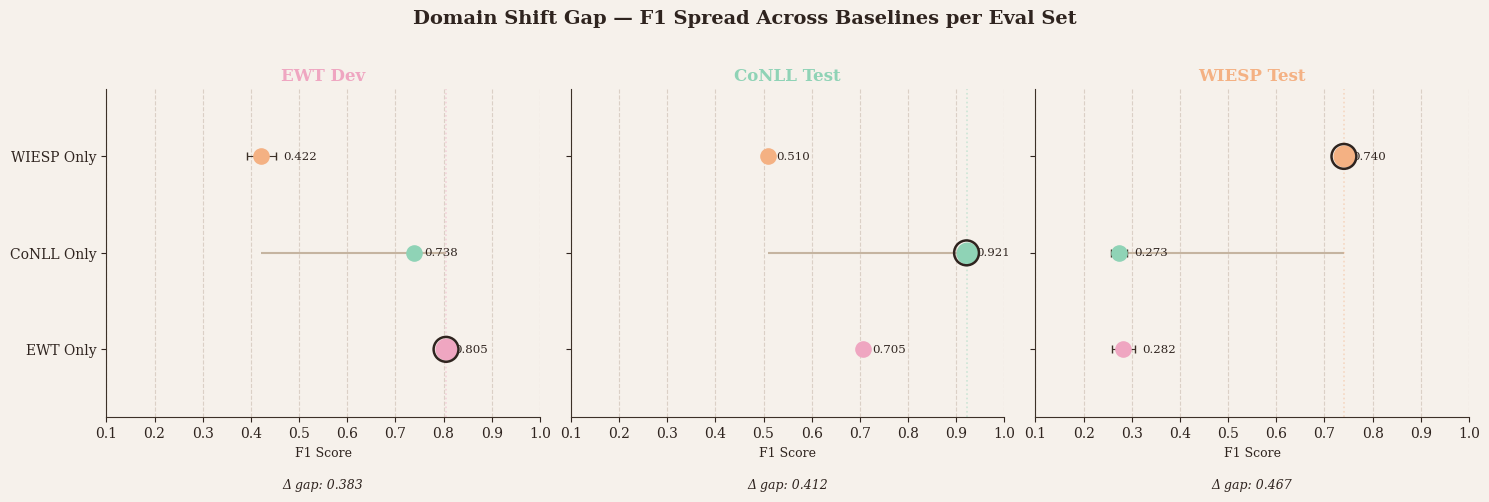

In [10]:

BASELINE_INFO_C = [
    ("baseline_ewt_only",   "EWT Only",   "EWT"),
    ("baseline_conll_only", "CoNLL Only", "CONLL"),
    ("baseline_astro_only", "WIESP Only", "WIESP"),
]
EVAL_INFO_C = [
    ("ewt_dev",    "EWT Dev",    "baseline_ewt_only",   "EWT"),
    ("conll_test", "CoNLL Test", "baseline_conll_only", "CONLL"),
    ("astro_test", "WIESP Test", "baseline_astro_only", "WIESP"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BG)
fig.suptitle(
    "Domain Shift Gap — F1 Spread Across Baselines per Eval Set",
    fontweight="bold", color=DARK, fontsize=14, y=1.02,
)

y_pos        = [0, 1, 2]
y_labels_lft = ["EWT Only", "CoNLL Only", "WIESP Only"]

for ax_idx, (es, es_label, indomain_b, eval_dom) in enumerate(EVAL_INFO_C):
    ax = axes[ax_idx]
    ax.set_facecolor(BG)
    eval_color = DOMAIN_COLORS[eval_dom]

    f1_means, f1_stds = [], []
    for b, _, _ in BASELINE_INFO_C:
        r = agg_df[(agg_df["exp_name"] == b) & (agg_df["eval_set"] == es)].iloc[0]
        f1_means.append(float(r[f"{F1_COL}_mean"]))
        f1_stds.append(float(r[f"{F1_COL}_std"]))

    # Single horizontal range line at centre row (y=1)
    ax.hlines(y=1, xmin=min(f1_means), xmax=max(f1_means),
              colors="#c5b4a0", linewidth=1.5, zorder=1)

    # Subtle vertical line at specialist F1
    indomain_idx  = [b for b, _, _ in BASELINE_INFO_C].index(indomain_b)
    specialist_f1 = f1_means[indomain_idx]
    ax.axvline(x=specialist_f1, color=eval_color, alpha=0.4, linestyle=":", lw=1.2, zorder=1)

    for bi, (b, b_label, b_dom) in enumerate(BASELINE_INFO_C):
        b_color   = DOMAIN_COLORS[b_dom]
        is_indom  = (b == indomain_b)
        dot_size  = 220 if is_indom else 120

        ax.errorbar(f1_means[bi], y_pos[bi], xerr=f1_stds[bi],
                    fmt="none", ecolor="#3d3128", elinewidth=0.8, capsize=3, zorder=3)
        ax.scatter(f1_means[bi], y_pos[bi], color=b_color, s=dot_size, zorder=4)
        if is_indom:
            ax.scatter(f1_means[bi], y_pos[bi], s=320,
                       facecolors="none", edgecolors="#2f241f", linewidths=1.8, zorder=5)
        ax.text(f1_means[bi] + f1_stds[bi] + 0.015, y_pos[bi],
                f"{f1_means[bi]:.3f}", va="center", fontsize=8.5, color=DARK)

    gap = specialist_f1 - min(f1_means)
    ax.text(0.5, -0.22, f"Δ gap: {gap:.3f}", transform=ax.transAxes,
            ha="center", fontsize=9, color=DARK, style="italic")

    ax.set_xlim(0.1, 1.0)
    ax.set_xlabel("F1 Score", color=DARK, fontsize=9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels_lft if ax_idx == 0 else [""] * 3, color=DARK)
    ax.set_ylim(-0.7, 2.7)
    ax.set_title(es_label, color=eval_color, fontweight="bold")
    ax.xaxis.grid(True, linestyle="--", alpha=0.25, color=GRID)
    ax.set_axisbelow(True)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_color(EDGE)
        ax.spines[sp].set_linewidth(0.8)

plt.tight_layout()
plt.show()


## Cell 11 — Plot 7: Slope Chart — Per-Type F1 Across Eval Sets

Each panel (one per trained baseline) shows how LOC, ORG, and PER F1 evolve across the three evaluation domains. The shaded column marks the in-domain evaluation; watch for lines that drop steeply when moving off-domain, and note which entity type is most or least portable across domains.

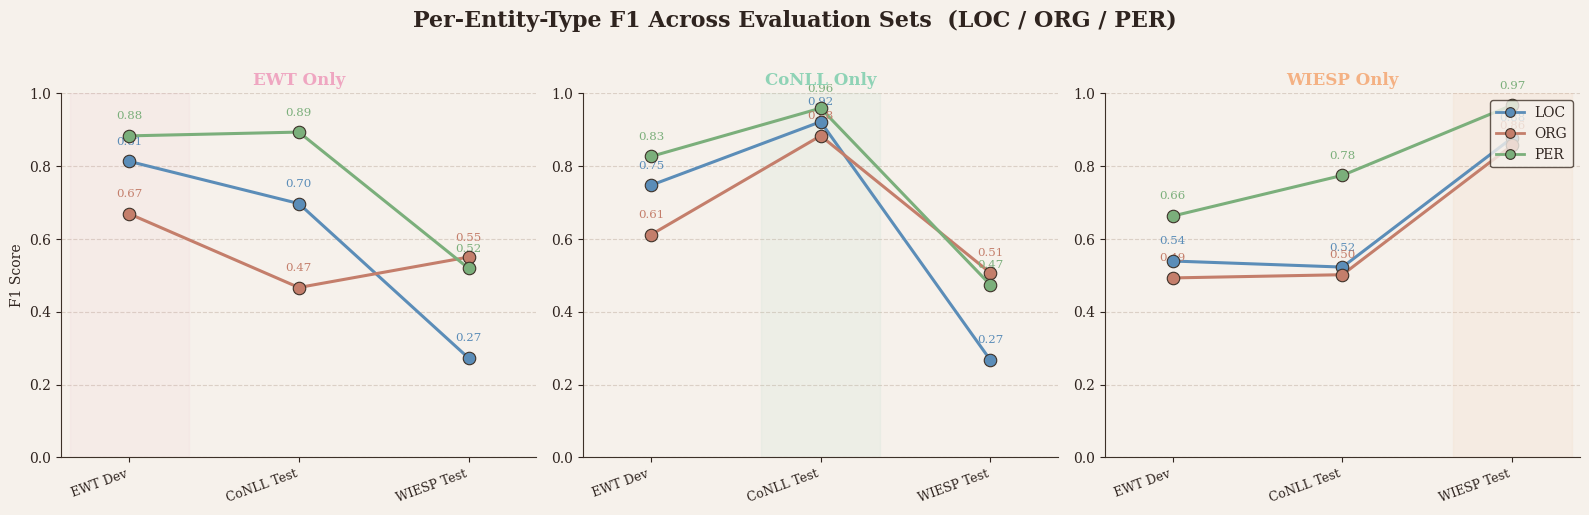

In [11]:

# ── Style constants (reuse from Cell 1) ───────────────────────────────────────
TYPE_COLORS  = {"LOC": "#5B8DB8", "ORG": "#C47E6B", "PER": "#7BAF7B"}
ENTITY_TYPES = ["LOC", "ORG", "PER"]
EVAL_LABELS_SLOPE = ["EWT Dev", "CoNLL Test", "WIESP Test"]

BASELINE_INFO_D = [
    ("baseline_ewt_only",   "EWT Only",   "EWT",   0),
    ("baseline_conll_only", "CoNLL Only", "CONLL", 1),
    ("baseline_astro_only", "WIESP Only", "WIESP", 2),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)

for ax_idx, (b, b_label, b_dom, indomain_x) in enumerate(BASELINE_INFO_D):
    ax = axes[ax_idx]
    ax.set_facecolor(BG)
    b_color = DOMAIN_COLORS[b_dom]

    ax.axvspan(indomain_x - 0.35, indomain_x + 0.35, alpha=0.08, color=b_color)

    for etype in ENTITY_TYPES:
        col_mean = f"f1_{etype}_mean"
        values = []
        for es in EVALSETS_ORDER:
            r   = agg_df[(agg_df["exp_name"] == b) & (agg_df["eval_set"] == es)].iloc[0]
            val = float(r[col_mean]) if (col_mean in agg_df.columns and not pd.isna(r[col_mean])) else np.nan
            values.append(val)

        valid = [(xi, yi) for xi, yi in enumerate(values) if not np.isnan(yi)]
        if len(valid) < 2:
            continue
        vx, vy = zip(*valid)
        ec = TYPE_COLORS[etype]
        ax.plot(vx, vy, lw=2.2, color=ec, solid_capstyle="round")
        ax.scatter(vx, vy, s=81, color=ec, edgecolors="#3d3128", linewidths=0.8, zorder=5)
        for xi, yi in zip(vx, vy):
            ax.text(xi, yi + 0.04, f"{yi:.2f}", fontsize=8.5, color=ec, ha="center", va="bottom")

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(EVAL_LABELS_SLOPE, rotation=20, ha="right", color=DARK, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_xlim(-0.4, 2.4)
    if ax_idx == 0:
        ax.set_ylabel("F1 Score", color=DARK)
    ax.set_title(b_label, fontweight="bold", color=b_color, fontsize=12)
    ax.yaxis.grid(True, linestyle="--", alpha=0.25, color=GRID)
    ax.set_axisbelow(True)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_color(EDGE)
        ax.spines[sp].set_linewidth(0.8)

    if ax_idx == 2:
        handles = [
            plt.Line2D([0], [0], color=TYPE_COLORS[e], lw=2, marker="o",
                       markersize=7, markeredgecolor="#3d3128", markeredgewidth=0.8, label=e)
            for e in ENTITY_TYPES
        ]
        ax.legend(handles=handles, loc="upper right", framealpha=0.8,
                  facecolor=BG, edgecolor=EDGE)

fig.suptitle(
    "Per-Entity-Type F1 Across Evaluation Sets  (LOC / ORG / PER)",
    fontweight="bold", color=DARK, fontsize=16, y=1.02,
)
plt.tight_layout()
plt.show()
